In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

In [40]:
df = pd.read_csv("ecommerce_sales_dataset.xls")
print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()

Shape: (10000, 26)
Columns: ['Order_ID', 'Order_Date', 'Year', 'Month', 'Quarter', 'Season', 'Customer_ID', 'Customer_Gender', 'Customer_Segment', 'Region', 'Country', 'Category', 'Sub_Category', 'Product_Name', 'Unit_Price', 'Quantity', 'Discount', 'Revenue', 'Cost', 'Profit', 'Profit_Margin_%', 'Shipping_Cost', 'Shipping_Method', 'Shipping_Days', 'Payment_Method', 'Order_Status']


,Order_ID,Order_Date,Year,Month,Quarter,Season,Customer_ID,Customer_Gender,Customer_Segment,Region,...,Discount,Revenue,Cost,Profit,Profit_Margin_%,Shipping_Cost,Shipping_Method,Shipping_Days,Payment_Method,Order_Status
0,ORD-000001,2023-01-18,2023,1,Q1,Winter,CUST-02791,Male,New,North America,...,0.00,3642.80,2444.11,1198.69,32.91,2.25,Economy,4,Google Pay,Delivered
1,ORD-000002,2023-11-13,2023,11,Q4,Fall,CUST-02763,Female,Regular,North America,...,0.25,33.88,28.32,5.56,16.41,4.72,Economy,5,Credit Card,Delivered
2,ORD-000003,2022-04-28,2022,4,Q2,Spring,CUST-05729,Male,Regular,North America,...,0.00,241.30,161.41,79.89,33.11,13.28,Standard,8,Credit Card,Processing
3,ORD-000004,2021-10-22,2021,10,Q4,Fall,CUST-06490,Female,Regular,Asia,...,0.00,654.50,369.16,285.34,43.60,31.11,Express,16,Google Pay,Processing
4,ORD-000005,2023-08-06,2023,8,Q3,Summer,CUST-07594,Female,Premium,Europe,...,0.20,178.82,118.69,60.13,33.63,8.44,Standard,5,Debit Card,Delivered


In [41]:
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          10000 non-null  str    
 1   Order_Date        10000 non-null  str    
 2   Year              10000 non-null  int64  
 3   Month             10000 non-null  int64  
 4   Quarter           10000 non-null  str    
 5   Season            10000 non-null  str    
 6   Customer_ID       10000 non-null  str    
 7   Customer_Gender   10000 non-null  str    
 8   Customer_Segment  10000 non-null  str    
 9   Region            10000 non-null  str    
 10  Country           10000 non-null  str    
 11  Category          10000 non-null  str    
 12  Sub_Category      10000 non-null  str    
 13  Product_Name      10000 non-null  str    
 14  Unit_Price        10000 non-null  float64
 15  Quantity          10000 non-null  int64  
 16  Discount          10000 non-null  floa

In [42]:
print("Null Values:")
print(df.isnull().sum())
print("Total nulls:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Null Values:
Order_ID            0
Order_Date          0
Year                0
Month               0
Quarter             0
Season              0
Customer_ID         0
Customer_Gender     0
Customer_Segment    0
Region              0
Country             0
Category            0
Sub_Category        0
Product_Name        0
Unit_Price          0
Quantity            0
Discount            0
Revenue             0
Cost                0
Profit              0
Profit_Margin_%     0
Shipping_Cost       0
Shipping_Method     0
Shipping_Days       0
Payment_Method      0
Order_Status        0
dtype: int64
Total nulls: 0
Duplicate rows: 0


In [43]:
df.describe().round(2)

,Year,Month,Unit_Price,Quantity,Discount,Revenue,Cost,Profit,Profit_Margin_%,Shipping_Cost,Shipping_Days
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,2022.76,6.60,236.31,2.73,0.18,528.44,384.67,143.76,23.65,32.30,11.44
std,0.88,3.41,380.90,2.04,0.16,1154.81,828.07,420.49,21.50,28.42,5.35
min,2021.00,1.00,10.01,1.00,0.00,5.33,4.85,-1572.90,-50.00,2.00,3.00
25%,2022.00,4.00,42.77,1.00,0.00,67.23,50.02,9.01,13.50,8.26,7.00
50%,2023.00,7.00,92.50,2.00,0.15,164.60,121.40,34.75,28.33,20.30,10.00
75%,2023.00,10.00,221.82,4.00,0.30,469.95,339.02,118.48,39.08,50.36,15.00
max,2024.00,12.00,2497.76,10.00,0.50,19966.50,15729.67,9144.15,54.99,99.99,25.00


In [44]:

df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Order_DayOfWeek'] = df['Order_Date'].dt.dayofweek
df['Is_Loss'] = (df['Profit'] < 0).astype(int)
df['Revenue_Per_Unit'] = df['Revenue'] / df['Quantity']
df['Discount_Category'] = pd.cut(df['Discount'],
    bins=[-0.01, 0.0, 0.10, 0.20, 0.30, 1.0],
    labels=['No Discount', 'Low (1-10%)', 'Medium (11-20%)', 'High (21-30%)', 'Very High (>30%)'])
print("Cleaning complete! New shape:", df.shape)

Cleaning complete! New shape: (10000, 30)


In [45]:
df_clean = df.copy()
df_clean['Order_Date'] = df_clean['Order_Date'].astype(str)
df_clean.to_csv("ecommerce_cleaned.csv", index=False)
print("Cleaned dataset saved: ecommerce_cleaned.csv")

Cleaned dataset saved: ecommerce_cleaned.csv


          Category  Total_Revenue  Total_Profit  Avg_Profit_Margin  \
0      Electronics     3382028.46     925448.15              23.34   
1   Home & Kitchen      892842.02     232421.45              23.02   
2         Clothing      407471.79     115705.29              24.80   
3    Books & Media      386644.46     105037.69              23.61   
4  Beauty & Health      215400.97      59025.73              23.48   

   Order_Count  
0         1977  
1         2008  
2         1977  
3         2043  
4         1995  


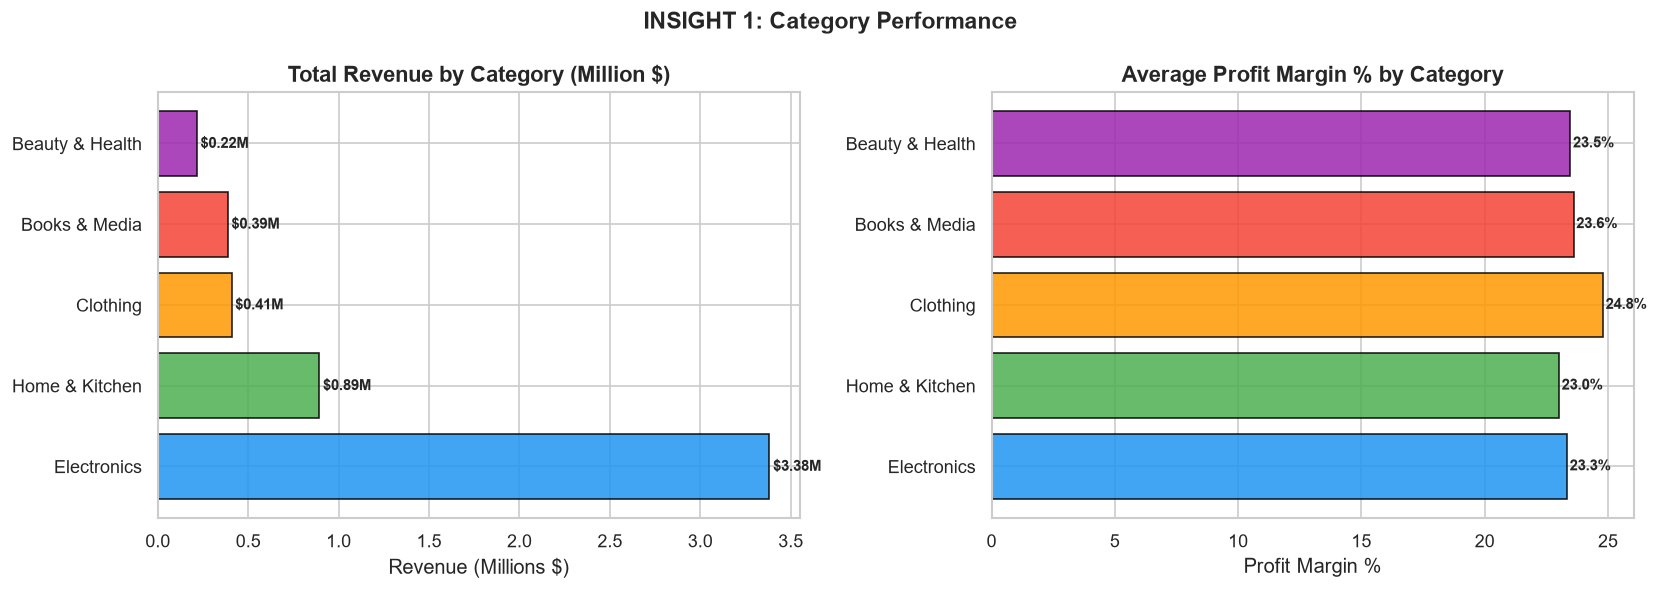

In [46]:

cat_stats = df.groupby('Category').agg(
    Total_Revenue=('Revenue','sum'),
    Total_Profit=('Profit','sum'),
    Avg_Profit_Margin=('Profit_Margin_%','mean'),
    Order_Count=('Order_ID','count')
).sort_values('Total_Revenue', ascending=False).reset_index()
print(cat_stats.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2196F3','#4CAF50','#FF9800','#F44336','#9C27B0']
axes[0].barh(cat_stats['Category'], cat_stats['Total_Revenue']/1e6, color=colors, edgecolor='black', alpha=0.85)
axes[0].set_title('Total Revenue by Category (Million $)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Revenue (Millions $)')
for i, v in enumerate(cat_stats['Total_Revenue']/1e6):
    axes[0].text(v+0.02, i, f'${v:.2f}M', va='center', fontweight='bold', fontsize=9)
axes[1].barh(cat_stats['Category'], cat_stats['Avg_Profit_Margin'], color=colors, edgecolor='black', alpha=0.85)
axes[1].set_title('Average Profit Margin % by Category', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Profit Margin %')
for i, v in enumerate(cat_stats['Avg_Profit_Margin']):
    axes[1].text(v+0.1, i, f'{v:.1f}%', va='center', fontweight='bold', fontsize=9)
plt.suptitle('INSIGHT 1: Category Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('insight1_category.png', dpi=150, bbox_inches='tight')
plt.show()

   Year     Revenue     Profit  Orders
0  2021   506060.36  148531.05     896
1  2022  1321845.01  356104.57    2687
2  2023  2308640.02  625276.12    4375
3  2024  1147842.31  307726.57    2042


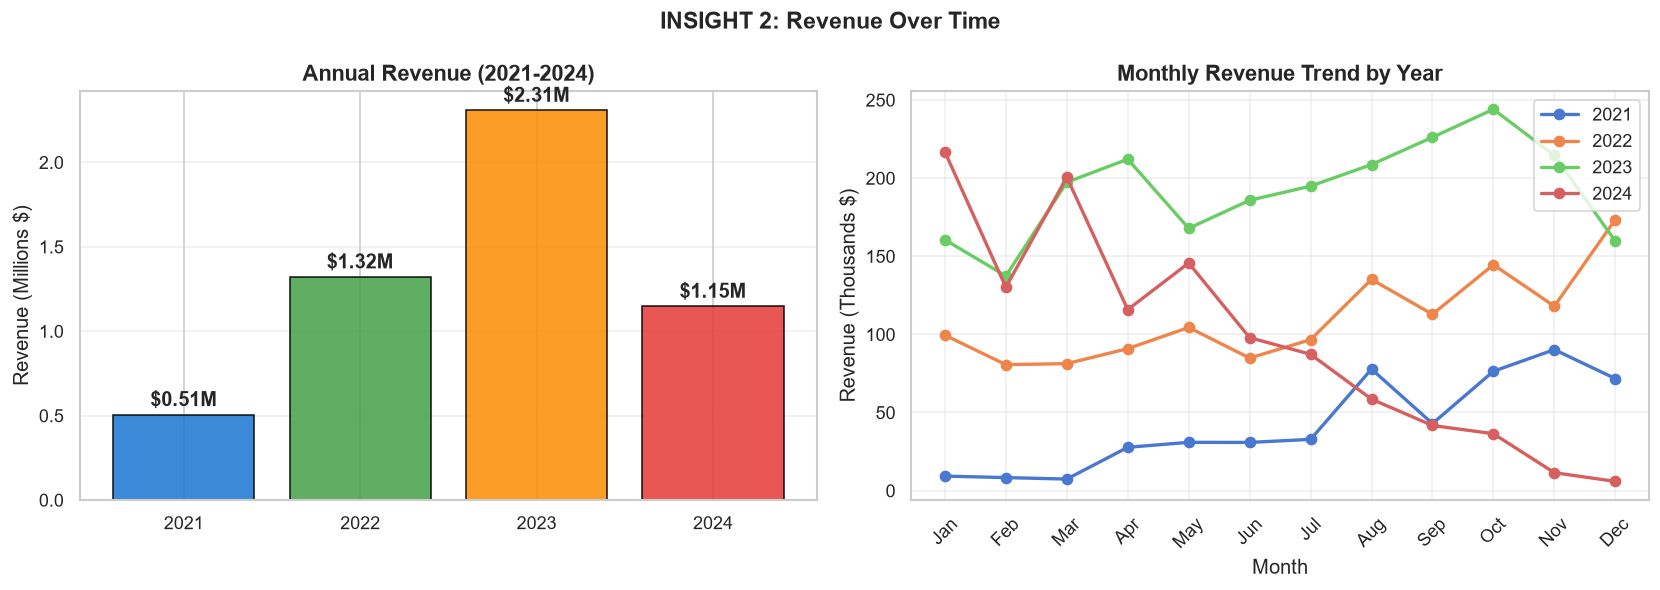

In [47]:

yearly = df.groupby('Year').agg(Revenue=('Revenue','sum'), Profit=('Profit','sum'), Orders=('Order_ID','count')).reset_index()
monthly = df.groupby(['Year','Month']).agg(Revenue=('Revenue','sum')).reset_index()
print(yearly)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(yearly['Year'].astype(str), yearly['Revenue']/1e6,
            color=['#1976D2','#43A047','#FB8C00','#E53935'], edgecolor='black', alpha=0.85)
axes[0].set_title('Annual Revenue (2021-2024)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Revenue (Millions $)')
for i, v in enumerate(yearly['Revenue']/1e6):
    axes[0].text(i, v+0.05, f'${v:.2f}M', ha='center', fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')
for year in sorted(monthly['Year'].unique()):
    ydata = monthly[monthly['Year']==year]
    axes[1].plot(ydata['Month'], ydata['Revenue']/1e3, marker='o', label=str(year), linewidth=2)
axes[1].set_title('Monthly Revenue Trend by Year', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Revenue (Thousands $)')
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.suptitle('INSIGHT 2: Revenue Over Time', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('insight2_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()

  Customer_Segment  Orders  Avg_Revenue  Total_Revenue
0              New    1942       524.15     1017899.86
1          Premium    1961       497.02      974664.57
2          Regular    5073       535.66     2717416.06
3              VIP    1024       560.94      574407.21


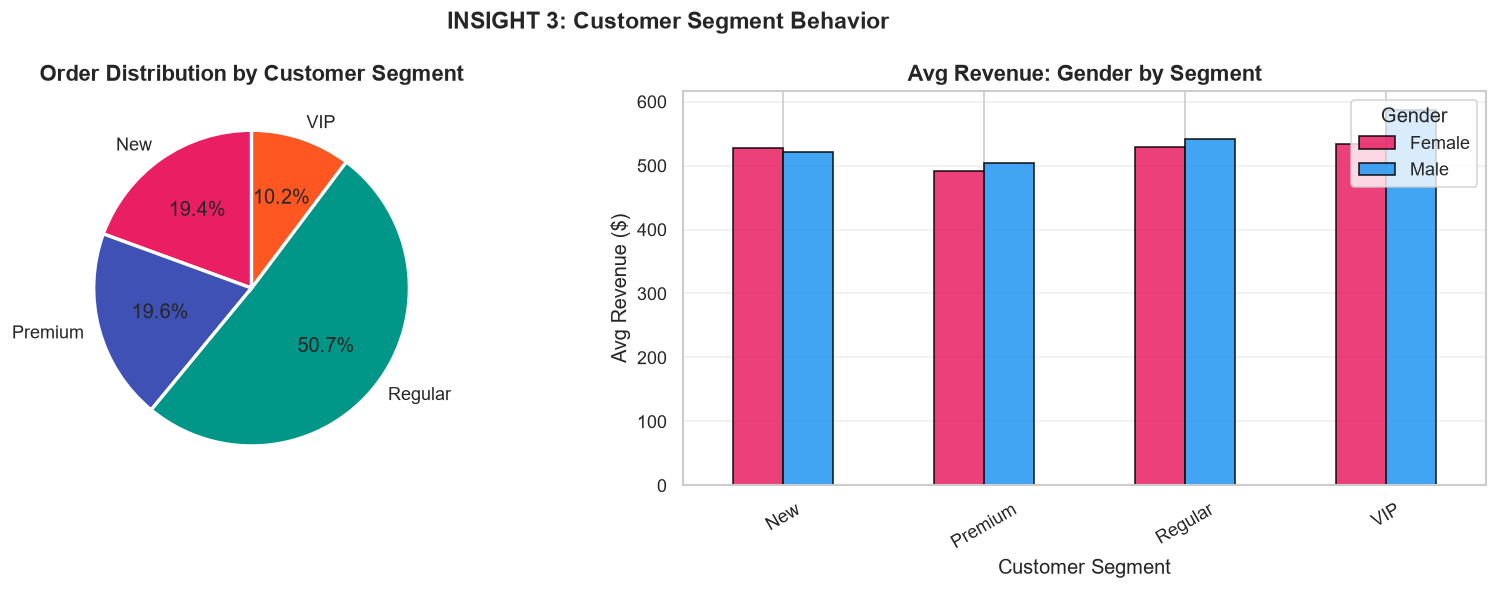

In [48]:

seg_stats = df.groupby('Customer_Segment').agg(
    Orders=('Order_ID','count'), Avg_Revenue=('Revenue','mean'), Total_Revenue=('Revenue','sum')).reset_index()
print(seg_stats.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
seg_colors = ['#E91E63','#3F51B5','#009688','#FF5722']
axes[0].pie(seg_stats['Orders'], labels=seg_stats['Customer_Segment'], autopct='%1.1f%%',
            colors=seg_colors, startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Order Distribution by Customer Segment', fontsize=13, fontweight='bold')
gender_rev = df.groupby(['Customer_Segment','Customer_Gender'])['Revenue'].mean().reset_index()
pivot = gender_rev.pivot(index='Customer_Segment', columns='Customer_Gender', values='Revenue')
pivot.plot(kind='bar', ax=axes[1], color=['#E91E63','#2196F3'], edgecolor='black', alpha=0.85)
axes[1].set_title('Avg Revenue: Gender by Segment', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Customer Segment')
axes[1].set_ylabel('Avg Revenue ($)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Gender')
axes[1].grid(alpha=0.3, axis='y')
plt.suptitle('INSIGHT 3: Customer Segment Behavior', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('insight3_customer.png', dpi=150, bbox_inches='tight')
plt.show()

  Discount_Category  Avg_Profit_Margin  Count
0       No Discount              40.14   2700
1       Low (1-10%)              35.25   1843
2   Medium (11-20%)              27.20   1785
3     High (21-30%)              17.28   1888
4  Very High (>30%)             -10.11   1784


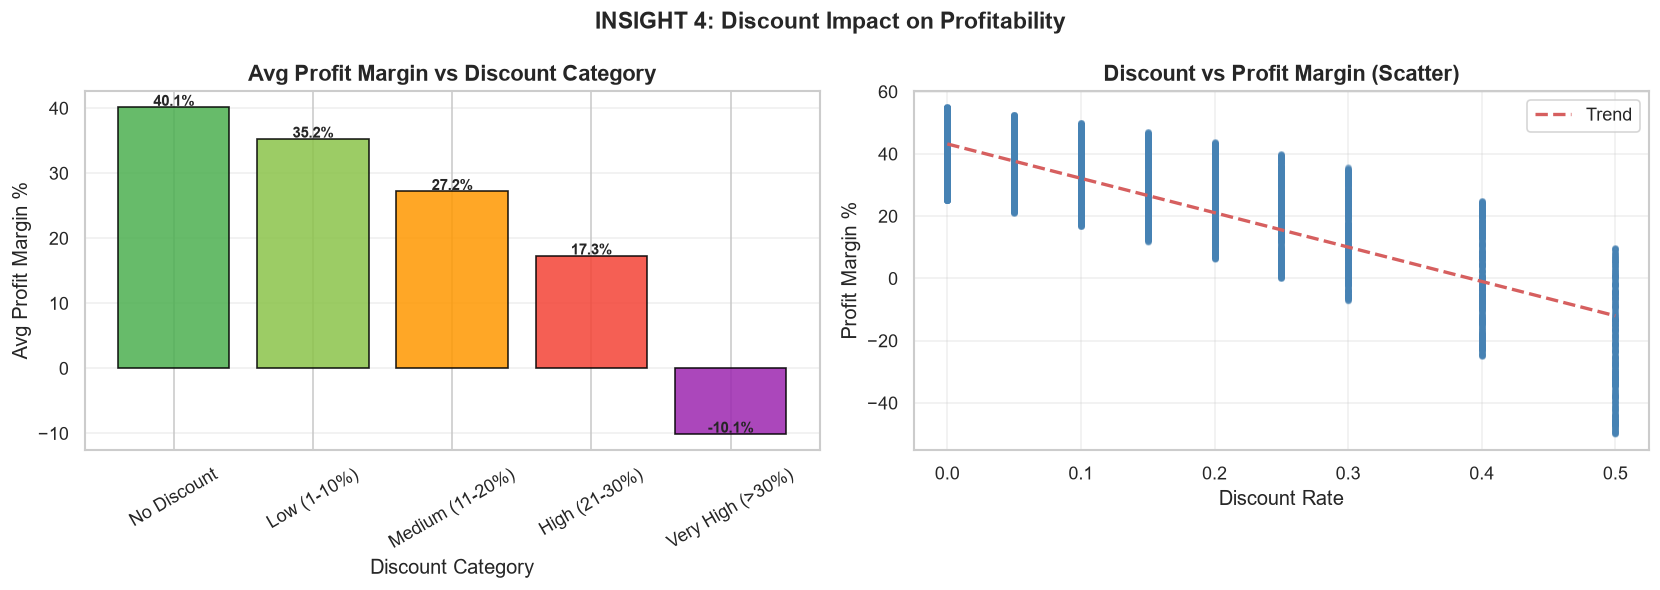

In [33]:

order_cats = ['No Discount','Low (1-10%)','Medium (11-20%)','High (21-30%)','Very High (>30%)']
disc_profit = df.groupby('Discount_Category', observed=True).agg(
    Avg_Profit_Margin=('Profit_Margin_%','mean'), Count=('Order_ID','count')).reindex(order_cats).reset_index()
print(disc_profit.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
disc_colors = ['#4CAF50','#8BC34A','#FF9800','#F44336','#9C27B0']
axes[0].bar(disc_profit['Discount_Category'], disc_profit['Avg_Profit_Margin'],
            color=disc_colors, edgecolor='black', alpha=0.85)
axes[0].set_title('Avg Profit Margin vs Discount Category', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Discount Category')
axes[0].set_ylabel('Avg Profit Margin %')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(alpha=0.3, axis='y')
for i, v in enumerate(disc_profit['Avg_Profit_Margin']):
    if not pd.isna(v):
        axes[0].text(i, v+0.2, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9)
axes[1].scatter(df['Discount'], df['Profit_Margin_%'], alpha=0.15, color='steelblue', s=10)
axes[1].set_title('Discount vs Profit Margin (Scatter)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Discount Rate')
axes[1].set_ylabel('Profit Margin %')
z = np.polyfit(df['Discount'], df['Profit_Margin_%'], 1)
p = np.poly1d(z)
x_line = np.linspace(0, df['Discount'].max(), 100)
axes[1].plot(x_line, p(x_line), 'r--', linewidth=2, label='Trend')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.suptitle('INSIGHT 4: Discount Impact on Profitability', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('insight4_discount.png', dpi=150, bbox_inches='tight')
plt.show()

          Region  Total_Revenue  Orders  Avg_Shipping_Days
0    Middle East     1348593.22    2458              12.51
1  North America     1331129.75    2602               6.47
2           Asia     1330007.18    2494              17.48
3         Europe     1274657.55    2446               9.47

  Shipping_Method  Count  Avg_Days  Avg_Cost
0         Economy   2516     11.46      6.09
1         Express   2504     11.34     35.08
2       Overnight   2522     11.51     75.07
3        Standard   2458     11.44     12.42


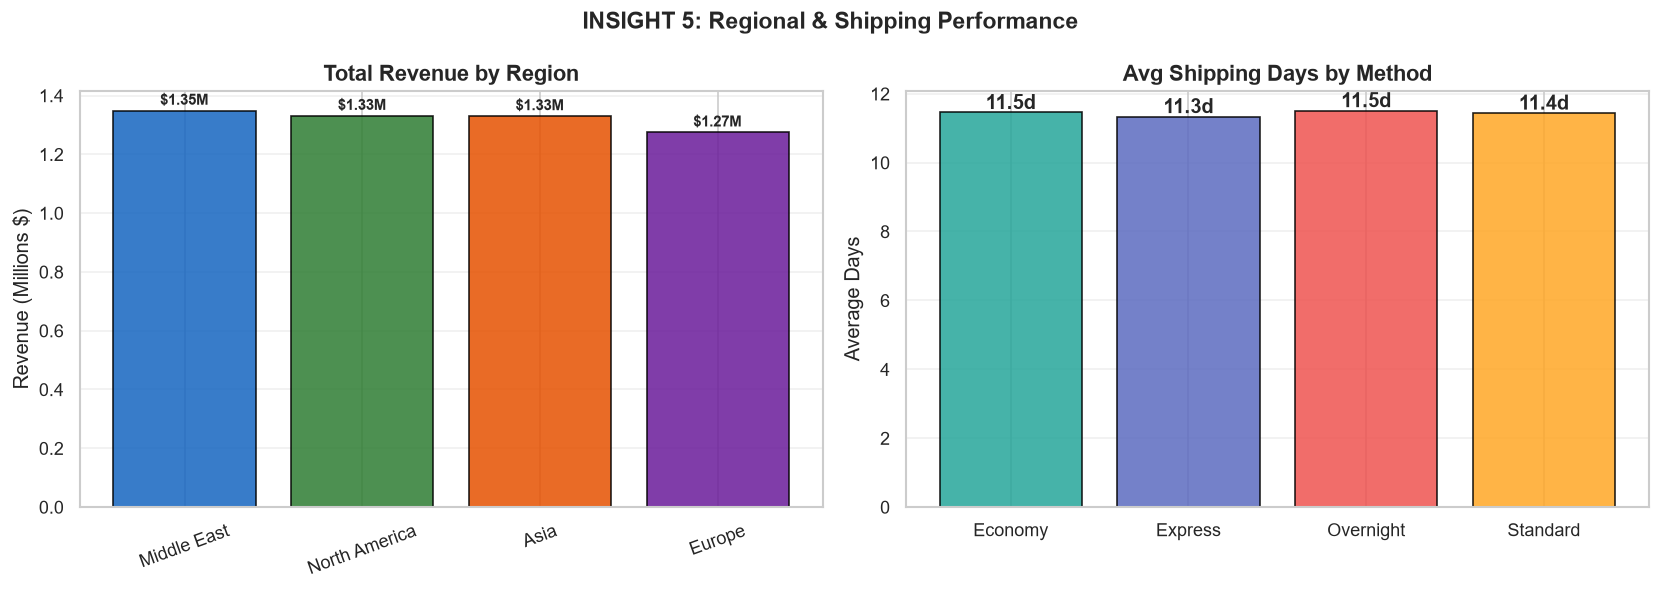

In [34]:

region_stats = df.groupby('Region').agg(
    Total_Revenue=('Revenue','sum'), Orders=('Order_ID','count'),
    Avg_Shipping_Days=('Shipping_Days','mean')).sort_values('Total_Revenue', ascending=False).reset_index()
ship_stats = df.groupby('Shipping_Method').agg(
    Count=('Order_ID','count'), Avg_Days=('Shipping_Days','mean'), Avg_Cost=('Shipping_Cost','mean')).reset_index()
print(region_stats.round(2))
print()
print(ship_stats.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
reg_colors = ['#1565C0','#2E7D32','#E65100','#6A1B9A']
axes[0].bar(region_stats['Region'], region_stats['Total_Revenue']/1e6,
            color=reg_colors, edgecolor='black', alpha=0.85)
axes[0].set_title('Total Revenue by Region', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Revenue (Millions $)')
for i, v in enumerate(region_stats['Total_Revenue']/1e6):
    axes[0].text(i, v+0.02, f'${v:.2f}M', ha='center', fontweight='bold', fontsize=9)
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(alpha=0.3, axis='y')
ship_colors = ['#26A69A','#5C6BC0','#EF5350','#FFA726']
axes[1].bar(ship_stats['Shipping_Method'], ship_stats['Avg_Days'],
            color=ship_colors, edgecolor='black', alpha=0.85)
axes[1].set_title('Avg Shipping Days by Method', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Average Days')
for i, v in enumerate(ship_stats['Avg_Days']):
    axes[1].text(i, v+0.1, f'{v:.1f}d', ha='center', fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')
plt.suptitle('INSIGHT 5: Regional & Shipping Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('insight5_region_shipping.png', dpi=150, bbox_inches='tight')
plt.show()

  Order_Status  Count  Total_Revenue  Total_Profit
0    Cancelled    908      499132.22     123283.92
1    Delivered   6273     3308169.75     909034.36
2   Processing    962      537441.33     150815.96
3     Returned   1857      939644.40     254504.07


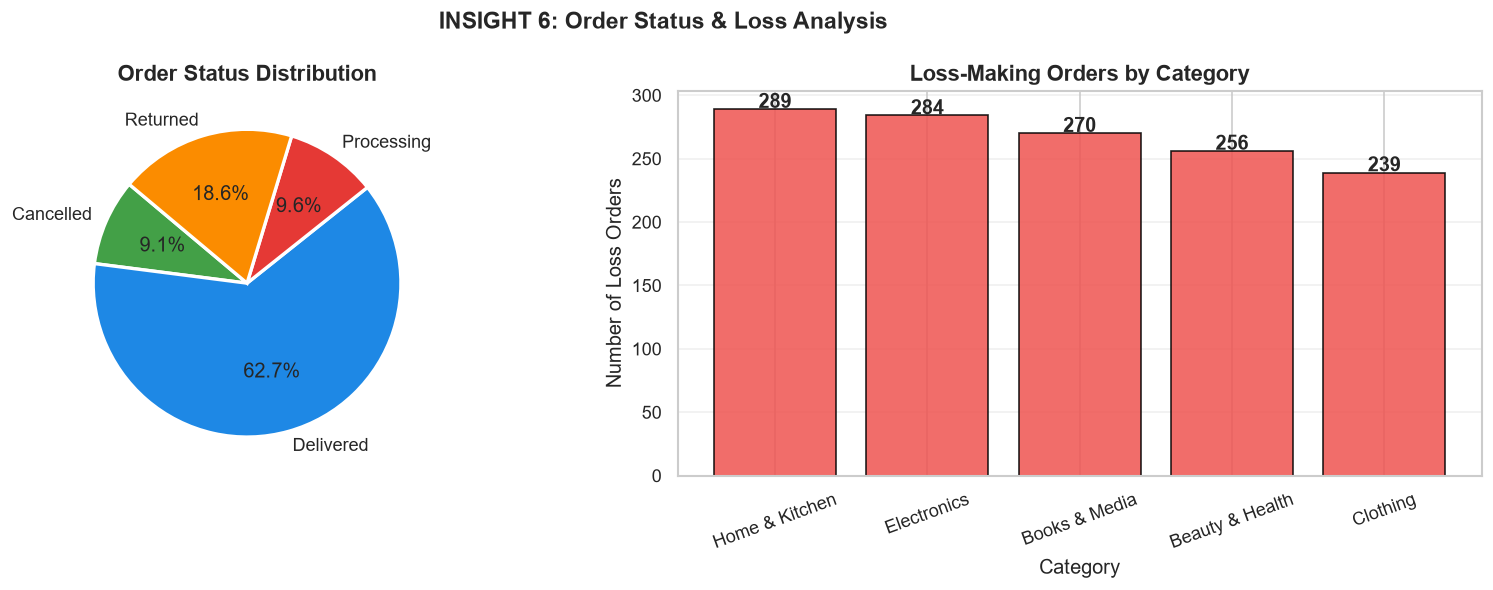

In [35]:

status_stats = df.groupby('Order_Status').agg(
    Count=('Order_ID','count'), Total_Revenue=('Revenue','sum'), Total_Profit=('Profit','sum')).reset_index()
loss_by_cat = df[df['Is_Loss']==1].groupby('Category')['Order_ID'].count().sort_values(ascending=False)
print(status_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
status_colors = ['#43A047','#1E88E5','#E53935','#FB8C00']
axes[0].pie(status_stats['Count'], labels=status_stats['Order_Status'], autopct='%1.1f%%',
            colors=status_colors, startangle=140, wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Order Status Distribution', fontsize=13, fontweight='bold')
axes[1].bar(loss_by_cat.index, loss_by_cat.values, color='#EF5350', edgecolor='black', alpha=0.85)
axes[1].set_title('Loss-Making Orders by Category', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Number of Loss Orders')
axes[1].tick_params(axis='x', rotation=20)
axes[1].grid(alpha=0.3, axis='y')
for i, v in enumerate(loss_by_cat.values):
    axes[1].text(i, v+1, str(v), ha='center', fontweight='bold')
plt.suptitle('INSIGHT 6: Order Status & Loss Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('insight6_order_status.png', dpi=150, bbox_inches='tight')
plt.show()

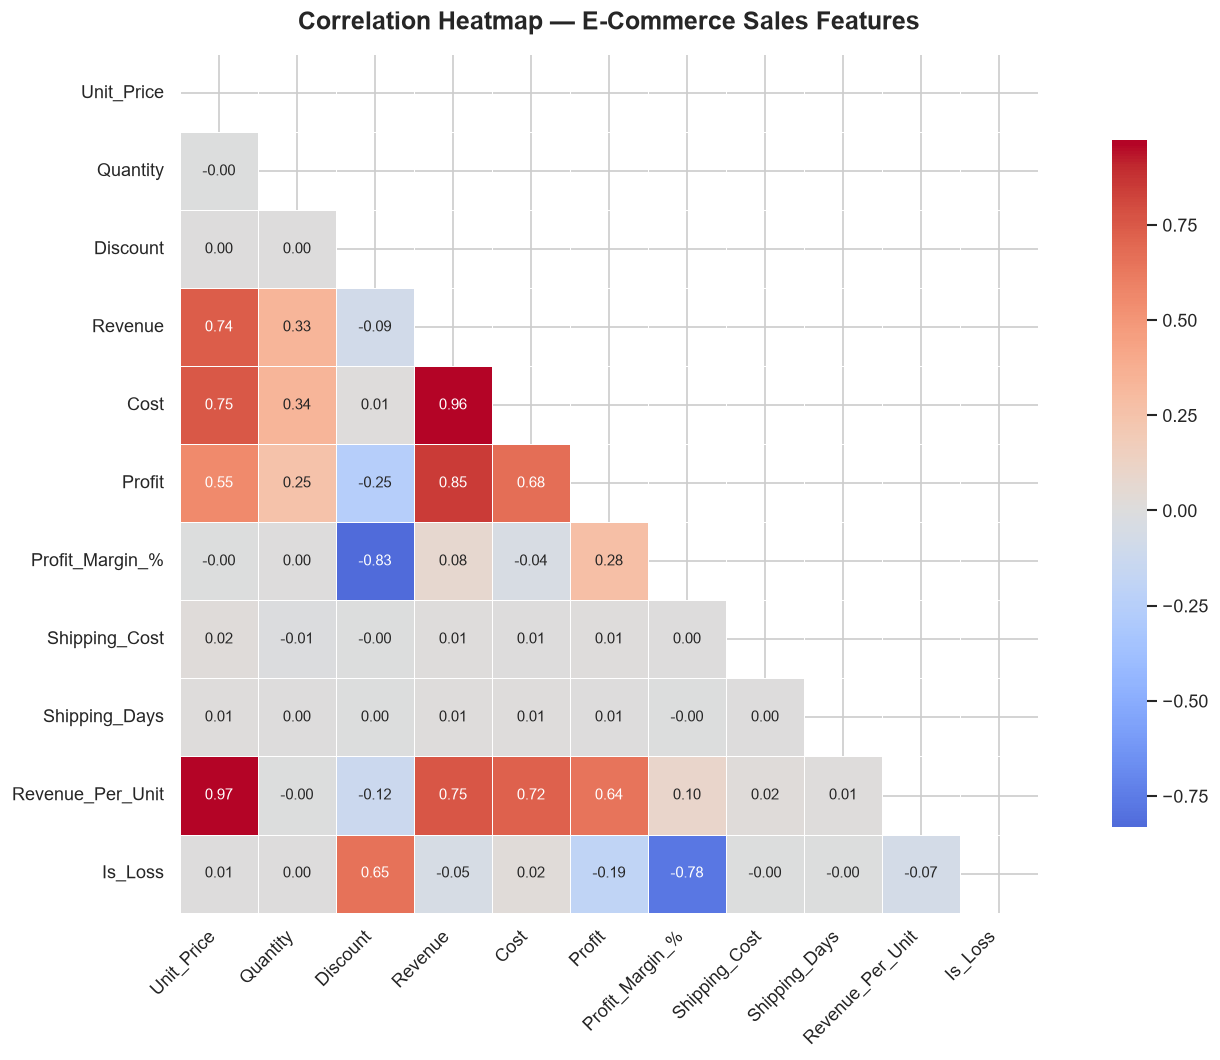

In [36]:
# CORRELATION HEATMAP
numeric_cols = ['Unit_Price','Quantity','Discount','Revenue','Cost',
                'Profit','Profit_Margin_%','Shipping_Cost','Shipping_Days','Revenue_Per_Unit','Is_Loss']
corr = df[numeric_cols].corr()
plt.figure(figsize=(13, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink':0.8}, annot_kws={'size':9})
plt.title('Correlation Heatmap — E-Commerce Sales Features', fontsize=15, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

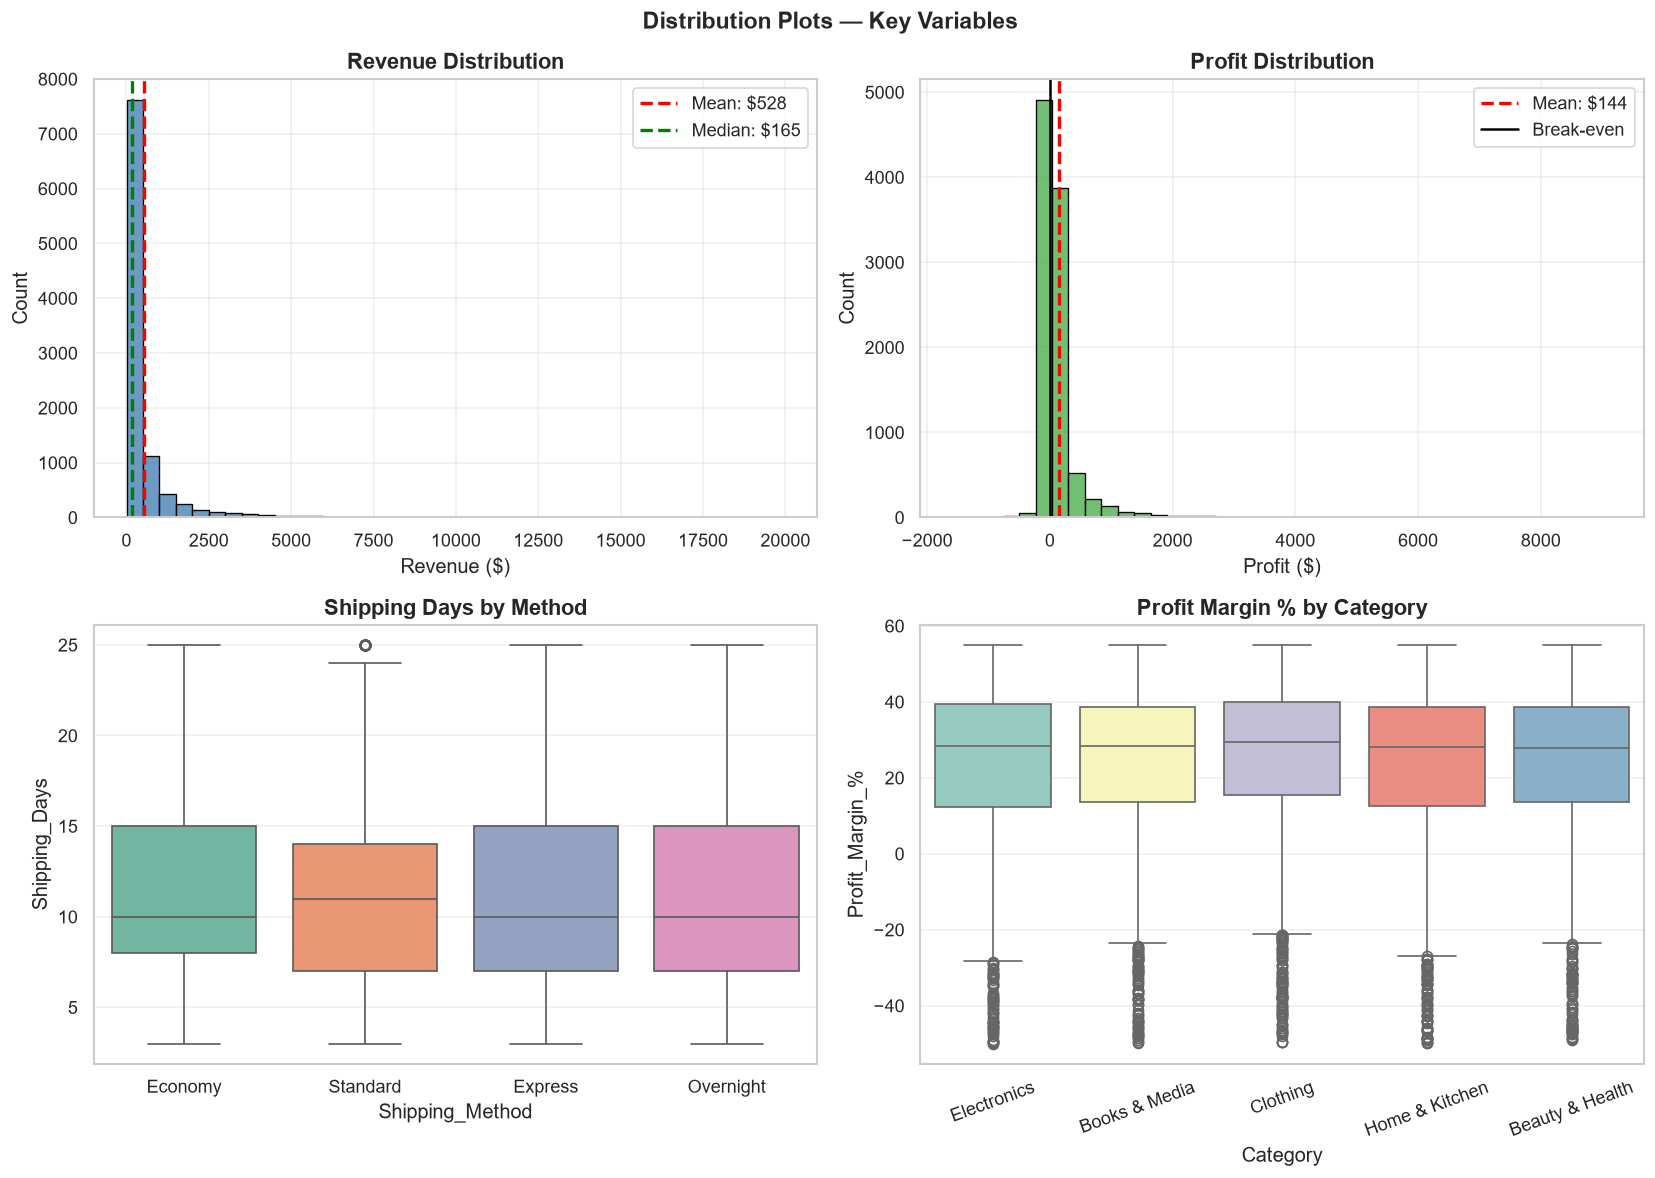

In [37]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(df['Revenue'], bins=40, ax=axes[0,0], color='steelblue', edgecolor='black', alpha=0.8)
axes[0,0].axvline(df['Revenue'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: ${df["Revenue"].mean():.0f}')
axes[0,0].axvline(df['Revenue'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: ${df["Revenue"].median():.0f}')
axes[0,0].set_title('Revenue Distribution', fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('Revenue ($)')
axes[0,0].legend()
axes[0,0].grid(alpha=0.3)
sns.histplot(df['Profit'], bins=40, ax=axes[0,1], color='#4CAF50', edgecolor='black', alpha=0.8)
axes[0,1].axvline(df['Profit'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: ${df["Profit"].mean():.0f}')
axes[0,1].axvline(0, color='black', linestyle='-', linewidth=1.5, label='Break-even')
axes[0,1].set_title('Profit Distribution', fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('Profit ($)')
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)
sns.boxplot(data=df, x='Shipping_Method', y='Shipping_Days', ax=axes[1,0], palette='Set2')
axes[1,0].set_title('Shipping Days by Method', fontsize=13, fontweight='bold')
axes[1,0].grid(alpha=0.3, axis='y')
sns.boxplot(data=df, x='Category', y='Profit_Margin_%', ax=axes[1,1], palette='Set3')
axes[1,1].set_title('Profit Margin % by Category', fontsize=13, fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=20)
axes[1,1].grid(alpha=0.3, axis='y')
plt.suptitle('Distribution Plots — Key Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('distribution_plots.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:

top_cat = df.groupby('Category')['Revenue'].sum().idxmax()
top_region = df.groupby('Region')['Revenue'].sum().idxmax()
best_seg = df.groupby('Customer_Segment')['Profit_Margin_%'].mean().idxmax()
return_rate = (df['Order_Status']=='Returned').mean()*100
cancel_rate = (df['Order_Status']=='Cancelled').mean()*100
loss_rate = df['Is_Loss'].mean()*100
disc_corr = df['Discount'].corr(df['Profit_Margin_%'])

print("CONCLUSIONS & KEY BUSINESS FINDINGS")
print("="*60)
print(f"1. TOP CATEGORY   : {top_cat} generates highest total revenue.")
print(f"2. BEST REGION    : {top_region} leads in revenue contribution.")
print(f"3. CUSTOMER VALUE : {best_seg} customers yield highest avg profit margin.")
print(f"4. DISCOUNT RISK  : Discount-Profit corr = {disc_corr:.3f}. High discounts erode margin.")
print(f"5. LOSS ORDERS    : {loss_rate:.1f}% of all orders result in a loss — needs pricing review.")
print(f"6. FULFILMENT RISK: Return={return_rate:.1f}% + Cancel={cancel_rate:.1f}% = {return_rate+cancel_rate:.1f}% revenue leakage.")
print(f"7. SHIPPING       : Economy method is slowest — customer satisfaction risk.")

CONCLUSIONS & KEY BUSINESS FINDINGS
1. TOP CATEGORY   : Electronics generates highest total revenue.
2. BEST REGION    : Middle East leads in revenue contribution.
3. CUSTOMER VALUE : Premium customers yield highest avg profit margin.
4. DISCOUNT RISK  : Discount-Profit corr = -0.831. High discounts erode margin.
5. LOSS ORDERS    : 13.4% of all orders result in a loss — needs pricing review.
6. FULFILMENT RISK: Return=18.6% + Cancel=9.1% = 27.6% revenue leakage.
7. SHIPPING       : Economy method is slowest — customer satisfaction risk.
